### Sel 0 - Persiapan Awal (Khusus Google Colab)

Kalau notebook ini dibuka di Google Colab, jalankan cell di bawah ini dulu untuk memastikan semua paket yang dipakai sudah tersedia. Kalau dijalankan di Jupyter lokal, cell ini tidak mengubah apa-apa.

In [1]:
# Sel 0: cek paket (sudah tersedia di venv / Colab)
import sklearn, pandas, numpy, matplotlib
print("Paket siap.")

Paket siap.


# Praktikum Machine Learning: Bab 8
## Support Vector Machine

| | |
|---|---|
| **Nama** | Ahmad Dandi Subhani |
| **NPM** | 202343500126 |
| **Kelas** | R7B |
| **Mata Kuliah** | Machine Learning |
| **Dosen** | Nurfidah Dwitiyanti, M.Si. |

> **Catatan:** notebook ini saya jalankan di Google Colab / Jupyter Notebook. Bab 8 ini mengerjakan **Latihan Praktikum Modul Bab 8 bagian 8.11**, memakai dataset **Breast Cancer** dari `sklearn.datasets.load_breast_cancer`. Tidak perlu file CSV apa pun.

## Ringkasan Konsep

- **Margin maksimum dan support vector:** SVM mencari hyperplane (garis pemisah) yang memisahkan dua kelas dengan jarak sejauh mungkin. Titik-titik data terdekat yang menentukan posisi garis itu disebut support vector.
- **Kernel trick:** trik untuk menangani data yang tidak bisa dipisah garis lurus, datanya dipetakan ke ruang berdimensi lebih tinggi. Kernel yang umum dipakai: linear, polynomial, dan RBF.
- **Parameter C:** mengatur trade-off antara margin yang lebar dan kesalahan klasifikasi. C kecil mentolerir beberapa salah klasifikasi demi margin lebar, C besar memaksa model mengikuti data training.
- **Parameter gamma:** mengatur seberapa jauh pengaruh satu titik training. Gamma kecil membuat pengaruhnya melebar (boundary halus), gamma besar membuat pengaruhnya sempit (boundary berlekuk).
- **Scaling wajib:** SVM sensitif terhadap skala fitur karena dia menghitung jarak, jadi fitur harus distandarisasi dulu (misalnya pakai StandardScaler) sebelum training.

## 8.11 Latihan Praktikum (Modul Bab 8)

Di bagian ini saya mengerjakan dua Latihan Praktikum dari modul Bab 8 bagian 8.11, yaitu perbandingan kernel SVM dan visualisasi decision boundary.

### Praktikum 1 - Perbandingan Kernel

**Tujuan:** membandingkan performa kernel linear, polynomial, dan RBF pada dataset yang sama.

Bagian ini saya mengerjakan Praktikum 8.7 dari modul. Saya memakai dataset Breast Cancer yang dibagi 80/20 (`random_state=42`), lalu tiap kernel dilatih lewat Pipeline berisi StandardScaler dan SVC. Di akhir saya tambahkan grafik batang untuk membandingkan akurasinya.

Kernel linear: akurasi = 0.956
Kernel poly: akurasi = 0.868
Kernel rbf: akurasi = 0.982


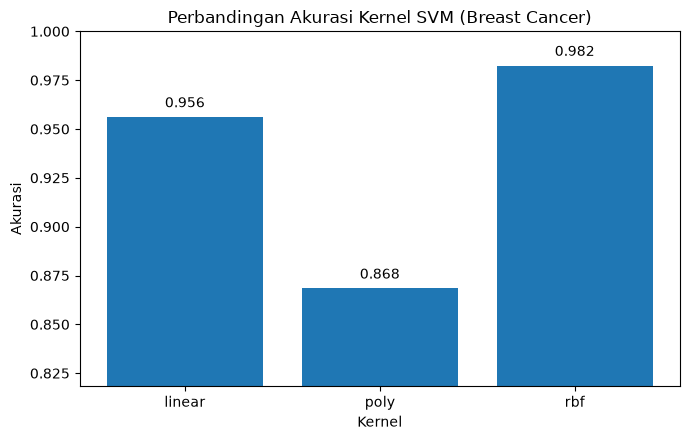

In [2]:
%matplotlib inline
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

hasil = {}
for kernel in ["linear", "poly", "rbf"]:
    model = Pipeline([("scaler",StandardScaler()),("svm",
        SVC(kernel=kernel))])
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"Kernel {kernel}: akurasi = {acc:.3f}")
    hasil[kernel] = acc

# Grafik batang perbandingan akurasi
plt.figure(figsize=(7, 4.5))
plt.bar(hasil.keys(), hasil.values())
plt.title("Perbandingan Akurasi Kernel SVM (Breast Cancer)")
plt.xlabel("Kernel")
plt.ylabel("Akurasi")
plt.ylim(min(hasil.values()) - 0.05, 1.0)
for k, v in hasil.items():
    plt.text(k, v + 0.005, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()

**Penjelasan outputnya:**
- Saya memakai dataset Breast Cancer (569 baris, 30 fitur) yang dibagi 80/20 dengan `random_state=42`, jadi data test-nya 114 baris.
- Hasilnya: kernel linear akurasinya 0.956, polynomial 0.868, dan RBF 0.982.
- Kernel RBF paling tinggi karena dia bisa membuat batas keputusan yang melengkung mengikuti pola data, sedangkan linear cuma bisa garis lurus.
- Kernel polynomial malah paling rendah di sini, kemungkinan bentuk polinomial bawaannya kurang cocok dengan pola dataset ini.
- Semua model dilatih lewat Pipeline yang diawali StandardScaler, jadi scaling dihitung dari data training saja dan tidak bocor ke data test.

### Praktikum 2 - Visualisasi Decision Boundary 2 Fitur

**Tujuan:** memvisualisasikan pengaruh kernel dan parameter C/gamma pada decision boundary.

**Instruksi:** pilih 2 fitur dari dataset `load_breast_cancer` (saya pakai `mean radius` dan `mean texture`, yaitu kolom 0 dan 1), latih SVM dengan beberapa kombinasi kernel/C/gamma, dan visualisasikan decision boundary masing-masing dalam subplot berdampingan.

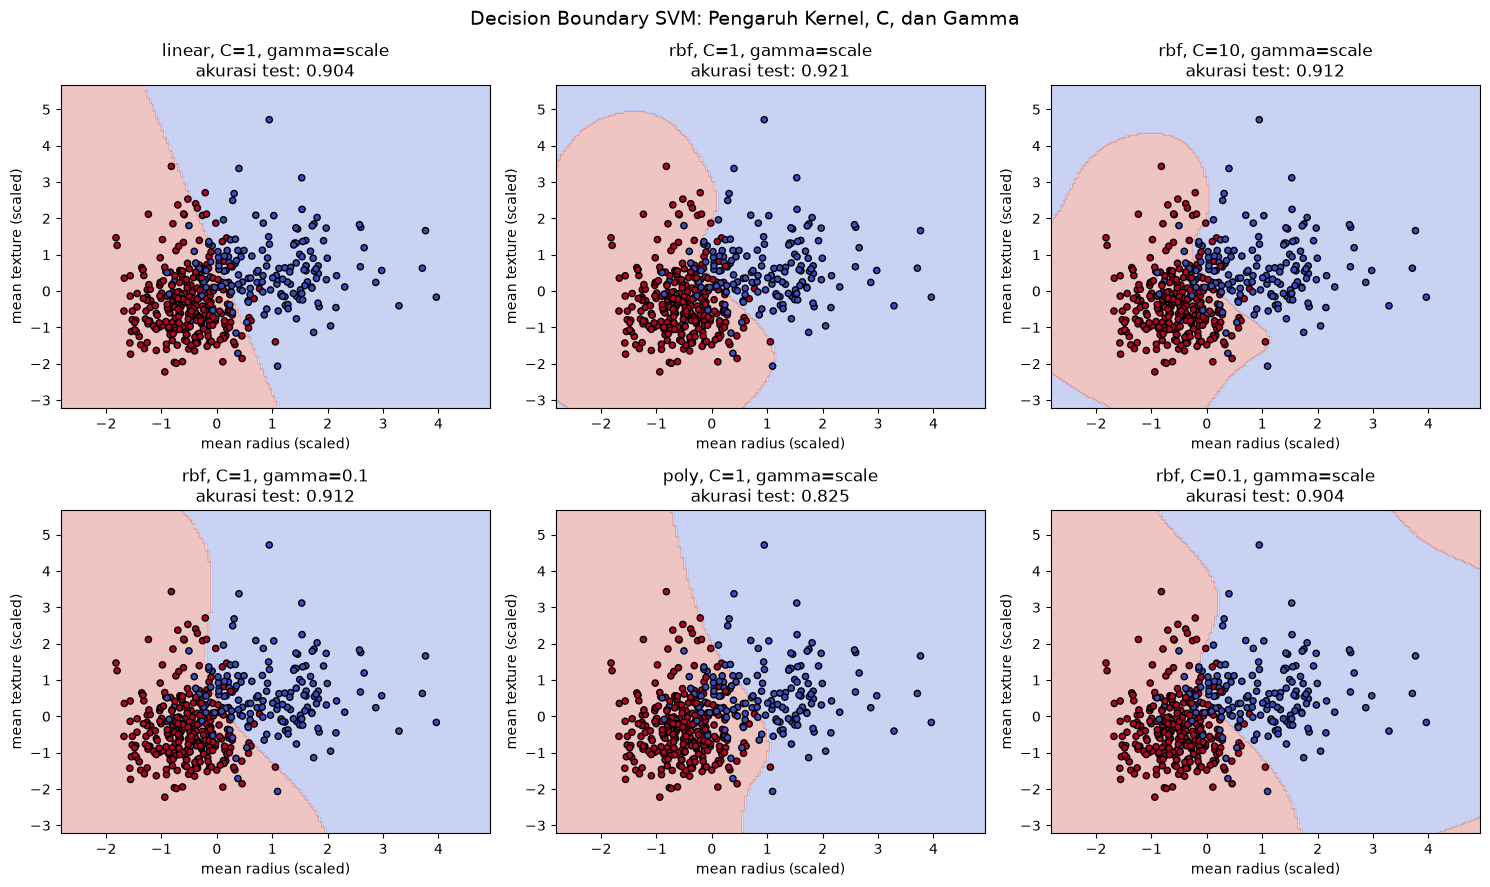

In [3]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X2 = X[:, [0, 1]]  # mean radius, mean texture
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, random_state=42)

scaler2 = StandardScaler()
X2_train_s = scaler2.fit_transform(X2_train)
X2_test_s = scaler2.transform(X2_test)

kombinasi = [
    ("linear", 1, "scale"),
    ("rbf", 1, "scale"),
    ("rbf", 10, "scale"),
    ("rbf", 1, 0.1),
    ("poly", 1, "scale"),
    ("rbf", 0.1, "scale"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (kernel, C, gamma) in zip(axes.flat, kombinasi):
    clf = SVC(kernel=kernel, C=C, gamma=gamma, random_state=42)
    clf.fit(X2_train_s, y2_train)
    x_min, x_max = X2_train_s[:, 0].min() - 1, X2_train_s[:, 0].max() + 1
    y_min, y_max = X2_train_s[:, 1].min() - 1, X2_train_s[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    ax.scatter(X2_train_s[:, 0], X2_train_s[:, 1], c=y2_train, cmap="coolwarm", edgecolors="k", s=20)
    acc2 = accuracy_score(y2_test, clf.predict(X2_test_s))
    ax.set_title(f"{kernel}, C={C}, gamma={gamma}\nakurasi test: {acc2:.3f}")
    ax.set_xlabel("mean radius (scaled)")
    ax.set_ylabel("mean texture (scaled)")

fig.suptitle("Decision Boundary SVM: Pengaruh Kernel, C, dan Gamma", fontsize=14)
plt.tight_layout()
plt.show()

**Penjelasan outputnya:**
- Saya hanya memakai 2 fitur (`mean radius` dan `mean texture`) supaya decision boundary-nya bisa digambar, fiturnya di-scale dulu baru datanya dibagi 80/20.
- linear, C=1 (akurasi 0.904): batasnya garis lurus, rapi tapi kaku, beberapa titik di dekat garis jadi salah kelas.
- rbf, C=1 (akurasi 0.921): batasnya melengkung mengikuti sebaran titik, akurasinya paling tinggi di antara enam kombinasi.
- rbf, C=10 (akurasi 0.912): C besar membuat margin makin ketat dan batasnya makin berlekuk mengikuti titik training, akurasinya sedikit turun dibanding C=1.
- rbf, gamma=0.1 (akurasi 0.912): gamma kecil membuat pengaruh tiap titik melebar sehingga batasnya jadi lebih halus.
- poly, C=1 (akurasi 0.825): akurasinya paling rendah, bentuk boundary polinomialnya kurang cocok untuk dua fitur ini.
- rbf, C=0.1 (akurasi 0.904): C kecil membuat margin longgar dan modelnya lebih sederhana dengan batas yang halus.

## Percobaan Mandiri

Tiga percobaan tambahan di luar Latihan Praktikum untuk melihat lebih jauh perilaku SVM: pengaruh parameter C terhadap margin, kemampuan kernel di data non-linear, dan pentingnya scaling fitur.


### Percobaan Mandiri 1 - C Kecil vs C Besar pada SVM Linear


C=0.01: train=0.862, test=0.886, support vector=249


C=100: train=0.888, test=0.904, support vector=129


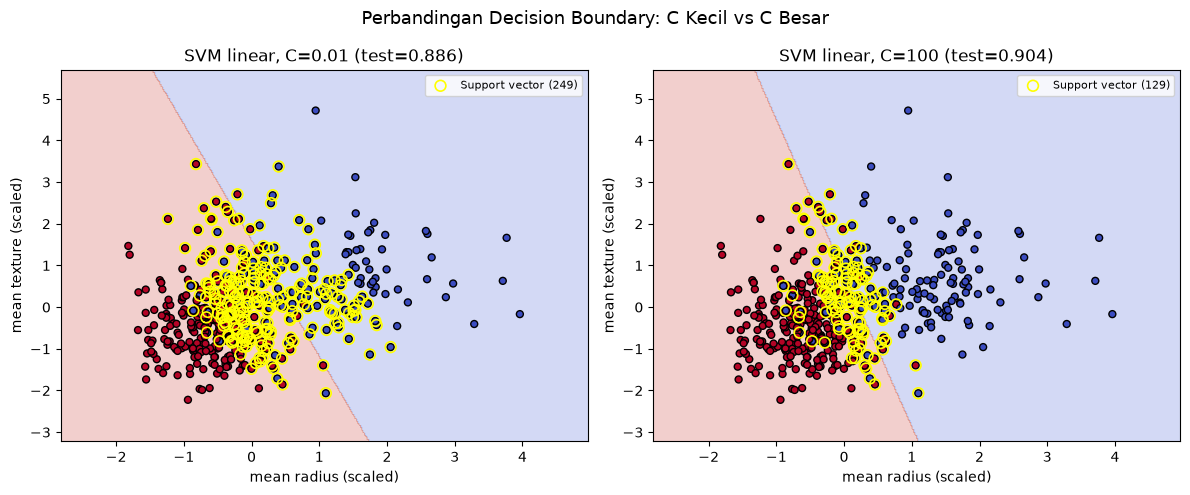

In [4]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

X, y = load_breast_cancer(return_X_y=True)
X2 = X[:, [0, 1]]  # mean radius dan mean texture
X_train, X_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, C in zip(axes, [0.01, 100]):
    clf = SVC(kernel="linear", C=C)
    clf.fit(X_train_s, y_train)
    acc_train = accuracy_score(y_train, clf.predict(X_train_s))
    acc_test = accuracy_score(y_test, clf.predict(X_test_s))
    n_sv = sum(clf.n_support_)
    print(f"C={C}: train={acc_train:.3f}, test={acc_test:.3f}, support vector={n_sv}")

    x_min, x_max = X_train_s[:, 0].min() - 1, X_train_s[:, 0].max() + 1
    y_min, y_max = X_train_s[:, 1].min() - 1, X_train_s[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.coolwarm)
    ax.scatter(X_train_s[:, 0], X_train_s[:, 1], c=y_train,
               cmap=plt.cm.coolwarm, edgecolor="k", s=25)
    ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
               facecolor="none", edgecolor="yellow", s=60, linewidth=1.2,
               label=f"Support vector ({n_sv})")
    ax.set_title(f"SVM linear, C={C} (test={acc_test:.3f})")
    ax.set_xlabel("mean radius (scaled)")
    ax.set_ylabel("mean texture (scaled)")
    ax.legend(loc="upper right", fontsize=8)
plt.suptitle("Perbandingan Decision Boundary: C Kecil vs C Besar", fontsize=13)
plt.tight_layout()
plt.show()


**Penjelasan outputnya:**
- Saya hanya memakai 2 fitur (`mean radius` dan `mean texture`) yang sudah di-scale supaya boundary-nya bisa digambar.
- C=0.01: akurasi train 0.862, test 0.886, support vector-nya 249. Batasnya lurus dan marginnya lebar, modelnya rela salah di beberapa titik training.
- C=100: akurasi train 0.888, test 0.904, support vector-nya cuma 129. Batasnya lebih ketat mengikuti titik-titik dan marginnya lebih sempit.
- Kesimpulan: C kecil membuat margin yang lebar dan lunak (support vector lebih banyak), sedangkan C besar membuat margin yang keras dan ketat mengikuti data.


### Percobaan Mandiri 2 - Kernel Linear vs RBF di Data Non-Linear


Kernel linear: akurasi test = 0.433


Kernel rbf: akurasi test = 0.817


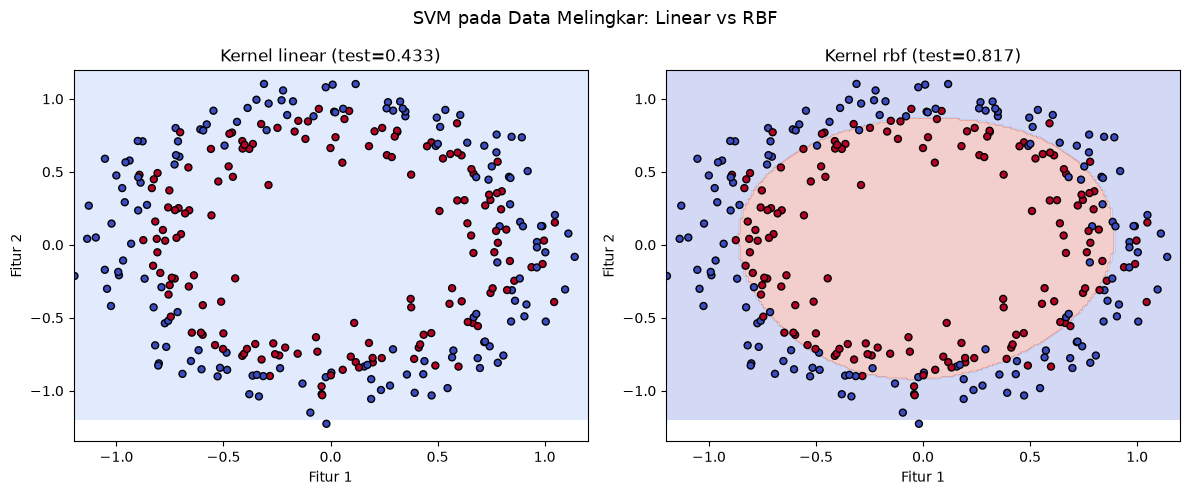

In [5]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

X, y = make_circles(n_samples=300, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, kernel in zip(axes, ["linear", "rbf"]):
    clf = SVC(kernel=kernel)
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    print(f"Kernel {kernel}: akurasi test = {acc:.3f}")

    xx, yy = np.meshgrid(np.linspace(-1.2, 1.2, 200),
                         np.linspace(-1.2, 1.2, 200))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.coolwarm)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolor="k", s=25)
    ax.set_title(f"Kernel {kernel} (test={acc:.3f})")
    ax.set_xlabel("Fitur 1")
    ax.set_ylabel("Fitur 2")
plt.suptitle("SVM pada Data Melingkar: Linear vs RBF", fontsize=13)
plt.tight_layout()
plt.show()


**Penjelasan outputnya:**
- Saya membuat data melingkar dengan `make_circles` (300 sampel) yang memang tidak bisa dipisah dengan garis lurus.
- Kernel linear: akurasi test cuma 0.433, bahkan lebih buruk dari tebakan acak. Dari grafiknya kelihatan garis lurusnya gagal memisahkan lingkaran dalam dari lingkaran luar.
- Kernel RBF: akurasi test 0.817, batasnya melingkar mengikuti bentuk data.
- Kesimpulan: kernel linear memang tidak cocok untuk data non-linear seperti ini, sedangkan kernel RBF bisa membuat batas yang melengkung.


### Percobaan Mandiri 3 - Scaling vs Tanpa Scaling


Tanpa scaling: akurasi test = 0.947
Dengan scaling: akurasi test = 0.982


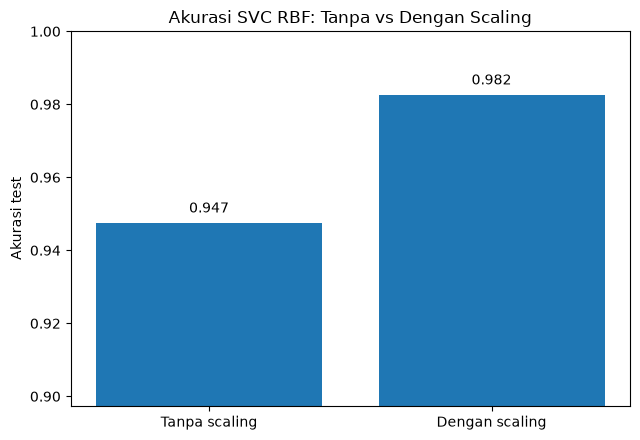

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

hasil = {}
clf_tanpa = SVC(kernel="rbf")
clf_tanpa.fit(X_train, y_train)
hasil["Tanpa scaling"] = accuracy_score(y_test, clf_tanpa.predict(X_test))

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
clf_dengan = SVC(kernel="rbf")
clf_dengan.fit(X_train_s, y_train)
hasil["Dengan scaling"] = accuracy_score(y_test, clf_dengan.predict(X_test_s))

for nama, acc in hasil.items():
    print(f"{nama}: akurasi test = {acc:.3f}")

plt.figure(figsize=(6.5, 4.5))
plt.bar(hasil.keys(), hasil.values())
plt.title("Akurasi SVC RBF: Tanpa vs Dengan Scaling")
plt.ylabel("Akurasi test")
plt.ylim(min(hasil.values()) - 0.05, 1.0)
for k, v in hasil.items():
    plt.text(k, v + 0.003, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()


**Penjelasan outputnya:**
- SVC dengan kernel RBF tanpa scaling: akurasi test 0.947.
- SVC dengan kernel RBF memakai StandardScaler: akurasi test 0.982, naik 0.035.
- Kesimpulan: SVM sangat sensitif terhadap skala fitur karena dia bekerja dengan menghitung jarak antar titik. Jadi scaling itu wajib sebelum melatih SVM.


## Kesimpulan Bab 8

- Kernel RBF memberi akurasi tertinggi (0.982) pada dataset Breast Cancer full, mengalahkan linear (0.956) dan polynomial (0.868).
- Parameter C mengatur seberapa ketat model mengikuti data training: C besar membuat boundary berlekuk, C kecil membuat boundary halus.
- Parameter gamma mengatur jangkauan pengaruh tiap titik: gamma kecil membuat boundary halus, gamma besar membuat boundary mengikuti titik-titik individual.
- Scaling fitur itu wajib sebelum melatih SVM, dan visualisasi 2 fitur membuktikan pilihan kernel sangat menentukan bentuk decision boundary.